In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='./scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    'scarf_datasets/bastidas-ponce_4K_pancreas-d15_rnaseq/data.zarr',
    nthreads=4,
    default_assay='RNA',
)

pseudotime_key = 'RNA_pseudotime'
validity_key = 'RNA_pseudotime__valid'

if pseudotime_key not in ds.cells.columns:
    pseudotime = ds.run_pseudotime_scoring(
        source_sink_key='RNA_cluster',
        sources=[1],
        sinks=[3],
    )
    pseudotime_key = pseudotime.pseudotime_key
    validity_key = pseudotime.validity_key

In [2]:
modules = ds.run_pseudotime_aggregation(
    cell_key=validity_key,
    pseudotime_key=pseudotime_key,
    cluster_label='pseudotime_clusters',
    n_clusters=15,
    window_size=200,
    chunk_size=100,
)

In [3]:
# Number of retained features and pseudotime bins
modules.data.shape

(12396, 100)

In [4]:
# Cluster assignment for each retained feature
modules.feature_clusters

array([ 7, 13,  4, ...,  8, 11, 14], shape=(12396,))

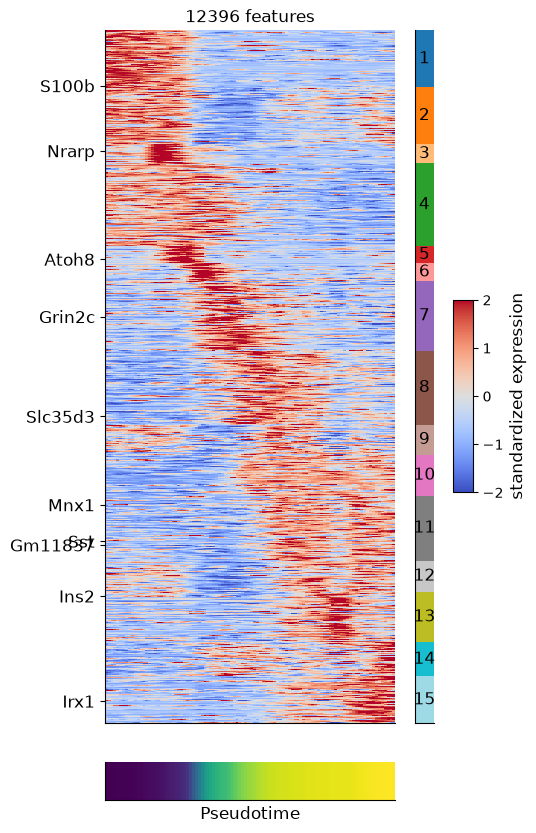

PlotResult(axes=4, tables=4, legends=3, scales=3, owns_figure=True, rendered=True)

In [5]:
# Highlighting some marker genes
genes_to_label = ['S100b', 'Nrarp', 'Atoh8', 'Grin2c', 'Slc35d3',
                  'Sst', 'Mnx1', 'Ins2', 'Gm11837', 'Irx1']

ds.plots.pseudotime_heatmap(
    cell_key=modules.cell_key,
    feat_key=modules.feature_key,
    feature_cluster_key=modules.cluster_key,
    pseudotime_key=modules.pseudotime_key,
    show_features=genes_to_label,
)

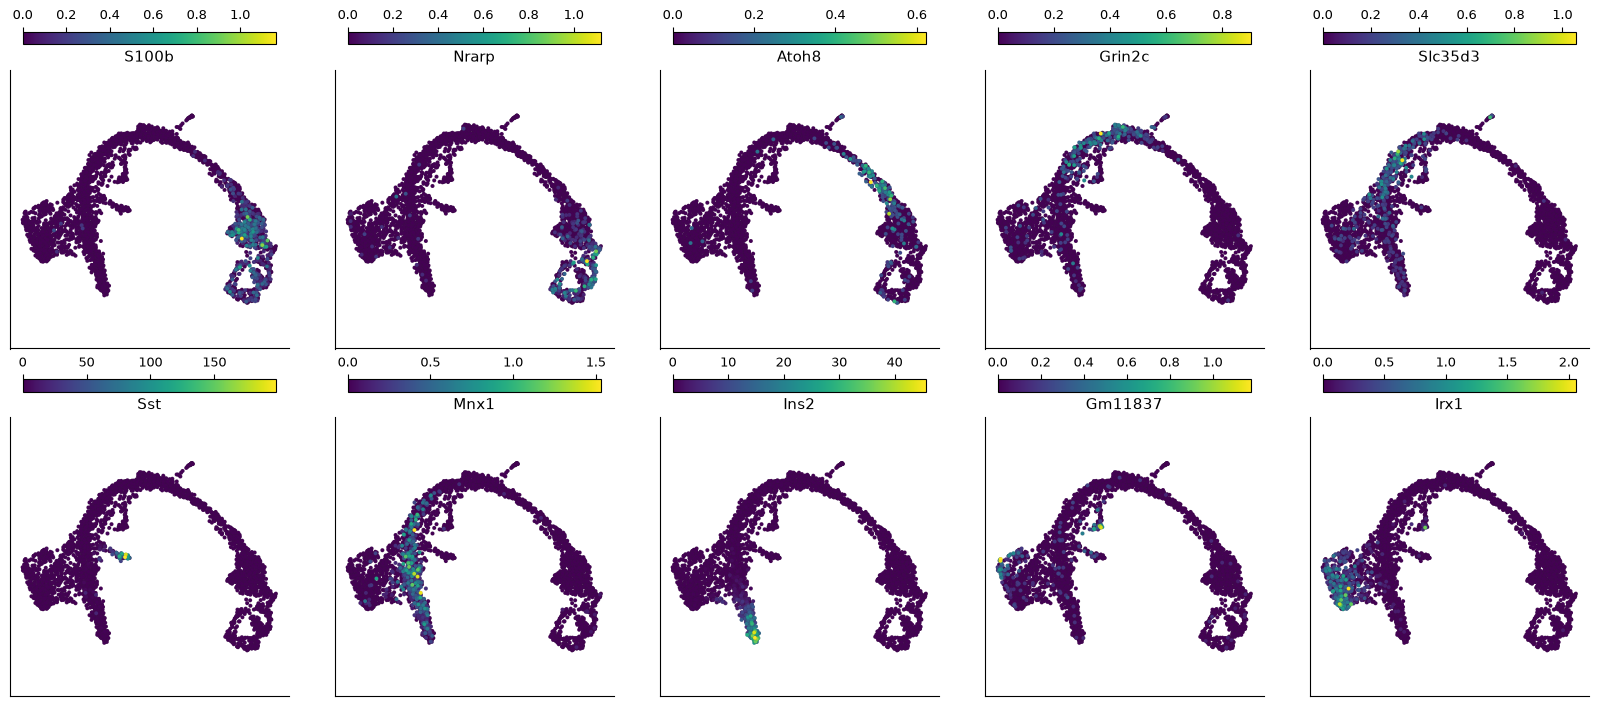

PlotResult(axes=10, tables=0, legends=10, scales=1, owns_figure=True, rendered=True)

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=genes_to_label,
    n_columns=5,
    sort_values=True,
)

In [7]:
ds.add_grouped_assay(
    group_key=modules.cluster_key,
    assay_label='PTIME_MODULES'
)

In [8]:
# DataStore summary showing `PTIME_MODULES` assay with 15 features (number of pseudotime based feature clusters)
ds

DataStore has 3413 (3696) cells with 2 assays: RNA PTIME_MODULES
   Cell metadata:
            'I', 'ids', 'names', 'PTIME_MODULES_nCounts', 'RNA_G2M_score', 
            'RNA_percentMito', 'G2M_score', 'RNA_pseudotime__valid', 'RNA_pseudotime', 'RNA_nFeatures', 
            'clusters_coarse', 'RNA_cell_cycle_phase', 'RNA_nCounts', 'RNA_cluster', 'RNA_percentRibo', 
            'PTIME_MODULES_nFeatures', 'RNA_S_score', 'clusters', 'S_score', 'RNA_UMAP2', 
            'RNA_UMAP1'
   PTIME_MODULES assay has 15 (15) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          
   RNA assay has 12497 (27998) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'highly_variable_genes', 
            'pseudotime_clusters', 'dropOuts', 'I__hvgs'

In [9]:
ds.PTIME_MODULES.feats.head()

,I,ids,names,dropOuts,nCells
0,True,group_1,group_1,0,3696
1,True,group_2,group_2,0,3696
2,True,group_3,group_3,0,3696
3,True,group_4,group_4,0,3696
4,True,group_5,group_5,0,3696


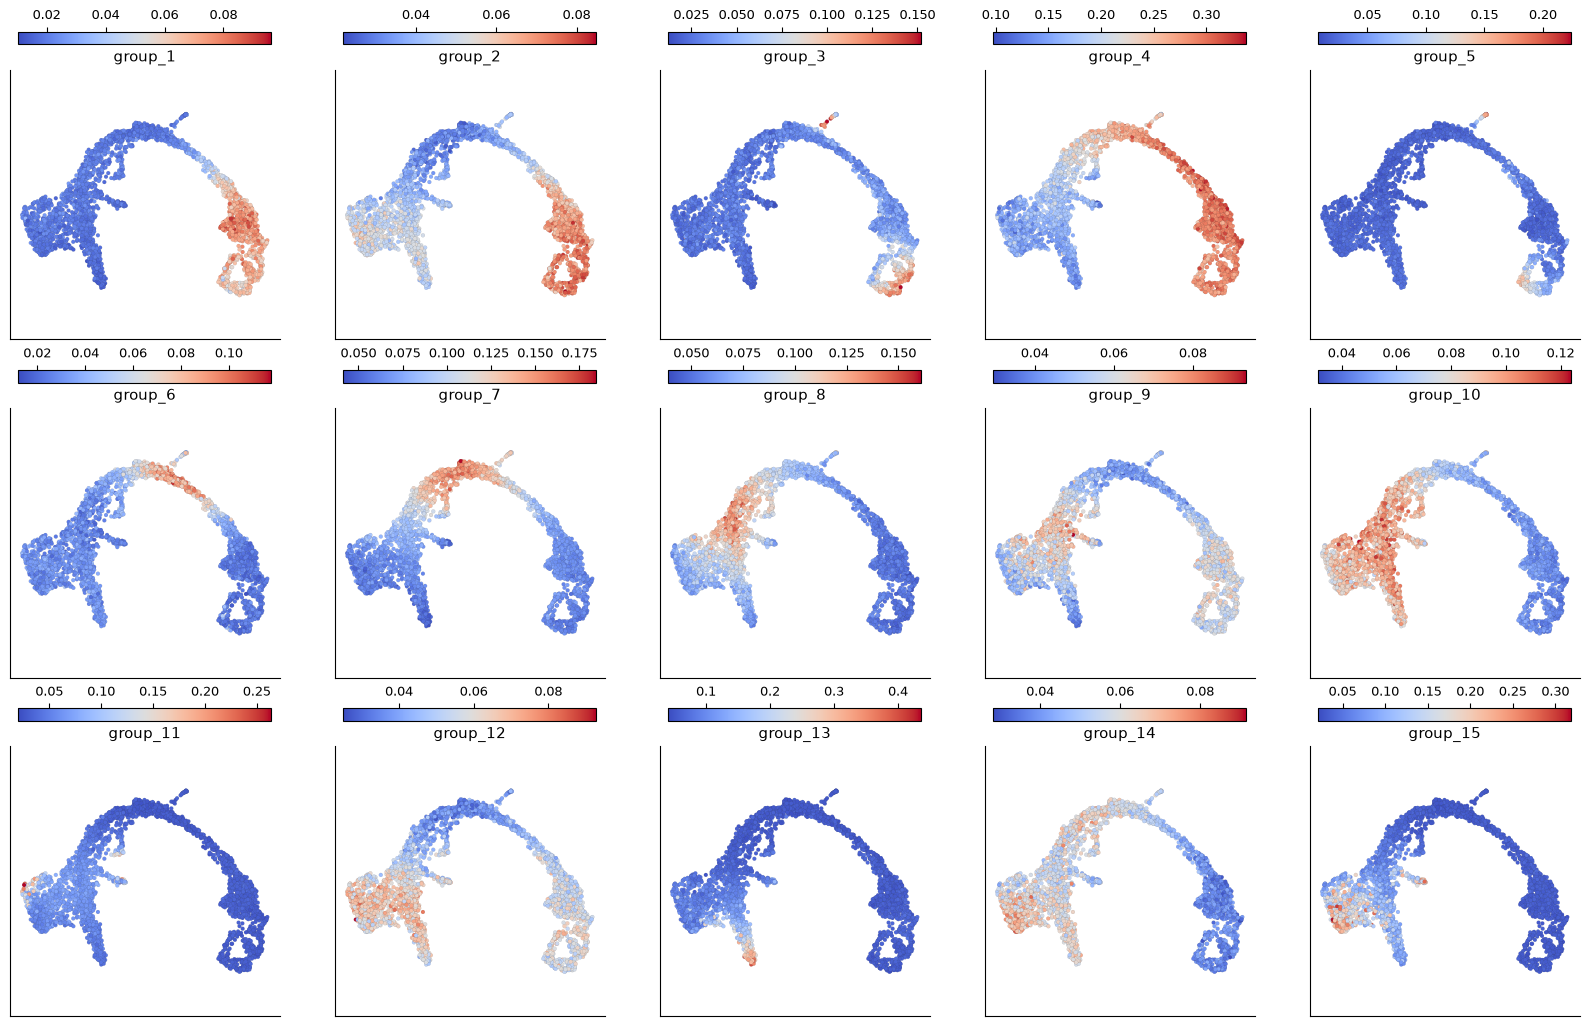

PlotResult(axes=15, tables=0, legends=15, scales=1, owns_figure=True, rendered=True)

In [10]:
n_clusters = 15
ds.plots.embedding(
    from_assay='PTIME_MODULES',
    layout_key='RNA_UMAP',
    color_by=[f"group_{i}" for i in range(1, n_clusters + 1)],
    n_columns=5,
    color_scale=splt.ColorScale(cmap='coolwarm'),
)

In [11]:
# Running marker search
ds.run_marker_search(group_key='RNA_cluster')

In [12]:
cell_cluster_markers = ds.get_markers(
    group_key='RNA_cluster',
    group_id='8',
).feature_name

cell_cluster_markers.head()

0        Ins2
1         Npy
2       Sytl4
3    Arhgap36
4     Tmem215
Name: feature_name, dtype: object

In [13]:
ptime_feat_clusts = ds.RNA.feats.to_pandas_dataframe(
    columns=['names', 'pseudotime_clusters']
)

beta_marker_names = set(cell_cluster_markers)
assigned = ptime_feat_clusts[ptime_feat_clusts.pseudotime_clusters != -1]
module_overlap = assigned.groupby('pseudotime_clusters')['names'].apply(
    lambda names: len(set(names) & beta_marker_names)
)
beta_module = int(module_overlap.idxmax())
beta_module

13

In [14]:
ptime_based_markers = ptime_feat_clusts.names[
    ptime_feat_clusts.pseudotime_clusters == beta_module
]
ptime_based_markers.head()

14            Vcpip1
25             Tram1
87             Uggt1
112           Lonrf2
242    4933417E11Rik
Name: names, dtype: object

In [15]:
# Number of genes captured by each approach
ptime_based_markers.shape, cell_cluster_markers.shape

((900,), (90,))

In [16]:
# Number of genes shared by both approaches, compared by gene name
len(set(ptime_based_markers) & set(cell_cluster_markers))

79

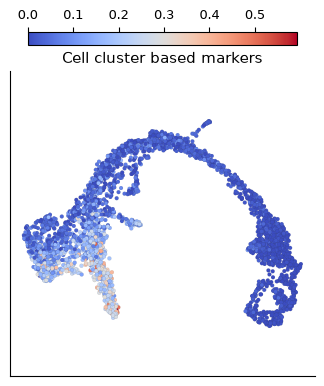

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [17]:
available_names = set(ptime_feat_clusts.names)
cell_only = sorted(
    (set(cell_cluster_markers) - set(ptime_based_markers)) & available_names
)
ds.cells.insert(
    column_name='Cell cluster based markers',
    values=ds.RNA.mean_features(cell_only),
    overwrite=True,
)

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='Cell cluster based markers',
    color_scale=splt.ColorScale(cmap='coolwarm'),
)

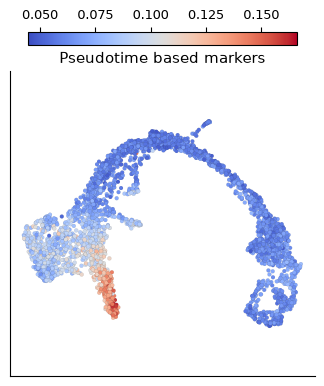

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [18]:
ptime_only = sorted(
    (set(ptime_based_markers) - set(cell_cluster_markers)) & available_names
)
ds.cells.insert(
    column_name='Pseudotime based markers',
    values=ds.RNA.mean_features(ptime_only),
    overwrite=True,
)

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='Pseudotime based markers',
    color_scale=splt.ColorScale(cmap='coolwarm'),
)